In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


# El módulo Glob

El módulo glob incluye funciones para buscar en una ruta todos los nombres de archivos y/o directorios que coincidan con un determinado patrón

In [ ]:
import os
import glob
import pandas as pd

os.chdir('/content/gdrive/MyDrive/Curso de Minería de Textos/Datasets/bestiario')  ##Cambiar por la ruta donde estén guardados los datasets de la clase


extension = 'txt'
all_filenames = [i for i in glob.glob('*.{}'.format(extension))]

all_filenames

['casa_tomada.txt',
 'bestiario.txt',
 'carta_a_una_senorita_en_paris.txt',
 'circe.txt',
 'las_puertas_del_cielo.txt',
 'lejana.txt',
 'cefalea.txt',
 'omnibus.txt']

In [ ]:
files

['/content/gdrive/MyDrive/Curso de Minería de Textos/Datasets/Menciones/Menciones 29En - 4 Feb.xlsx',
 '/content/gdrive/MyDrive/Curso de Minería de Textos/Datasets/Menciones/Menciones Abril 1 -8.xlsm.xlsx',
 '/content/gdrive/MyDrive/Curso de Minería de Textos/Datasets/Menciones/Menciones Abril 9 -15.xlsm',
 '/content/gdrive/MyDrive/Curso de Minería de Textos/Datasets/Menciones/Menciones test.xlsx',
 '/content/gdrive/MyDrive/Curso de Minería de Textos/Datasets/Menciones/Menciones 23-28 enero.xlsx']

In [ ]:
files= glob.glob(r'/content/gdrive/MyDrive/Curso de Minería de Textos/Datasets/Menciones/*.xls*')

df= pd.DataFrame()
for i in range(0,len(files)):
            df_1 = pd.read_excel(files[i])
            df = pd.concat([df_1,df])
df.head()

,Message,Sentimiento
0,"@DIRECTVGOAyuda Hola, tengo una serie de pregu...",Neutro
1,@DIRECTVGO Hola @DIRECTVGO hice la compra del ...,Negativo
2,"@DIRECTVGOAyuda Hola, ¿por qué me sale ""Fallo ...",Negativo
3,"@DIRECTVGOAyuda Ayer entré normalmente, pude a...",Negativo
4,es que ayer podia entrar perfectamente a Direc...,Negativo


In [ ]:
files

['/content/gdrive/MyDrive/Curso de Minería de Textos/Datasets/Menciones/Menciones 29En - 4 Feb.xlsx',
 '/content/gdrive/MyDrive/Curso de Minería de Textos/Datasets/Menciones/Menciones Abril 1 -8.xlsm.xlsx',
 '/content/gdrive/MyDrive/Curso de Minería de Textos/Datasets/Menciones/Menciones Abril 9 -15.xlsm',
 '/content/gdrive/MyDrive/Curso de Minería de Textos/Datasets/Menciones/Menciones test.xlsx',
 '/content/gdrive/MyDrive/Curso de Minería de Textos/Datasets/Menciones/Menciones 23-28 enero.xlsx']

In [ ]:
#Tenemos una parte de la base en la que el sentimiento ya fue clasificado de manera manual, que es la que utilizaremos para entrenar los modelos supervisados, y otra en la que el campo sentimiento está vacío (es en la que buscaremos predecir).

# Ahora están ambas bases en un sólo archivo, vamos a separarlas:
df_sin_clasif= df[df.Sentimiento.isna()]
df_clasificado= df[~df.Sentimiento.isna()]

Exportar los archivos

In [ ]:
#Para exportar a un CSV
from google.colab import files
df.iloc[0:1000].to_csv('descarga.csv')
files.download('descarga.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Para Exportar a Google Sheets

from google.colab import auth
auth.authenticate_user()
import gspread
from oauth2client.client import GoogleCredentials as GC
gc = gspread.authorize(GC.get_application_default())
from gspread_dataframe import set_with_dataframe
title = 'Sheet de prueba'
gc.create(title)
sheet = gc.open(title).sheet1
set_with_dataframe(sheet, pd.DataFrame(df_sin_clasif))

# Leer un archivo .zip desde la web

In [ ]:
#@title
os.chdir('/content/')
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip

# se aloja en archivos, en el menú de la izquierda en el cuaderno

--2022-10-28 23:16:52--  https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 579043 (565K) [application/x-httpd-php]
Saving to: ‘bank.zip.1’

bank.zip.1          100%[===================>] 565.47K   731KB/s    in 0.8s    

2022-10-28 23:16:53 (731 KB/s) - ‘bank.zip.1’ saved [579043/579043]



In [ ]:
#@title
# extraemos el contenido del .zip
! unzip /content/bank.zip
# se aloja en Files, en el mismo lugar que el .zip

Archive:  /content/bank.zip
replace bank-full.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
#@title
import pandas as pd
# leemos el archivo .csv
data=pd.read_csv('/content/bank.csv', sep=';')

# observamos los primeros valores del conjunto de datos

data.head(5)


# SQL y Python

Manipulación de datos con gramática de SQL

In [ ]:
import pandas.io.sql as pd_sql #librería para escribir un archivo en formato db
import sqlite3 as sql # sqlite3 está construido en Python

con = sql.connect("testing.db") #nos conectamos a una base sql que llamamos testing
pd_sql.to_sql(df,'m4',con) # escribimos una tabla con el conjunto de datos que llamamos "data" en la base de datos testing
con.close()

db=sql.connect("testing.db") # nos conectamos a la base

rs=db.execute('select *, case when Message like "%cancelar%" then "Neg" end sentimiento2 from m4') #ejecutamos un selec sobre la tabla contenida en la base

data_sql=pd.DataFrame(data=rs) # convertimos a Data Frame el resultado del query
data_final=data_sql.drop(columns=0) #borramos la primer columna que es el indice de la tabla original

#le damos nombres a las columnas
data_final.columns=['Message','Sentimiento', 'SentimientoSQL']
data_final

,Message,Sentimiento,SentimientoSQL
0,Exigimos cadena perpetua para Arturo Vidal,Neutro,None
1,Que es cuma este wn...\nCero decencia\nBorrach...,Neutro,None
2,Tomo como reyyy artuloooooo jjajaj,Neutro,None
3,El rey de los flyates,Neutro,None
4,mi reysito bello,Neutro,None
...,...,...,...
8740,Muy buena la App veo todo el fútbol en vivo,Positivo,None
8741,Muy bueno,Positivo,None
8742,@cryssoft @DIRECTVGO Yo la tengo y funciona bien.,Positivo,None
8743,Me encanta mi @DIRECTVGO 😍 donde voy tengo tod...,Positivo,None


# Clasificación de sentimiento mediante reglas

In [ ]:
df['neg'] = df['Message'].astype(str).apply(lambda x : 1 if 'desilu' in x.lower() else  1 if 'caro' in x.lower() else 1 if 'devoluci' in x.lower() else   0)

df['neutr'] = df['Message'].astype(str).apply(lambda x : 1 if 'cuanto' in x.lower() else  1 if 'precio' in x.lower() else 1 if 'sale' in x.lower() else   0)

df['pos'] = df['Message'].astype(str).apply(lambda x : 1 if 'RT' in x.lower() else  1 if 'recomiendo' in x.lower() else 1 if 'bueno' in x.lower() else   0)


In [ ]:
#Chequear
df[df['neg']==1][0:10]

,Message,Sentimiento,neg,neutr,pos
180,@DIRECTVGO @macaro8182 Quien fue el primer cam...,Neutro,1,0,0
740,Directv es pésimo y caro yo lo tengo y me pare...,Negativo,1,0,0
756,"@DIRECTVGO DirecTV, pícaros , es la empresa qu...",Negativo,1,0,0
760,"@DIRECTVGO porqué sacaron los canales Max, Max...",Negativo,1,0,0
780,El internet es lento y caro :v,Neutro,1,0,0
1082,@DIRECTVGOAyuda Me indican los asesores que CD...,Negativo,1,0,0
1143,@DIRECTVGO Ninguna x q es muy caro,Negativo,1,0,0
1144,esta interesante pero aun es muy caro comparad...,Negativo,1,0,0
369,"No me gustó nada es final, que desilusión lo d...",NaN,1,0,0
861,Años de estudio en publicidad y los weones le ...,NaN,1,0,0


In [ ]:
palabrasNeg =  ['no se ve','cancelar','triste']

df['neg'] = df['Message'].apply(lambda x: any([k in str(x) for k in palabrasNeg]))

In [ ]:
df[df['neg']==1][0:10]

# Análisis de Concordancia

En un corpus de prueba de NLTK

In [ ]:
import nltk
nltk.download('gutenberg')

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

In [ ]:
from nltk.corpus import gutenberg
from nltk.text import Text
corpus = gutenberg.words('melville-moby_dick.txt')
text = Text(corpus)
text.concordance("monstrous")

Displaying 11 of 11 matches:
ong the former , one was of a most monstrous size . ... This came towards us , 
ON OF THE PSALMS . " Touching that monstrous bulk of the whale or ork we have r
ll over with a heathenish array of monstrous clubs and spears . Some were thick
d as you gazed , and wondered what monstrous cannibal and savage could ever hav
that has survived the flood ; most monstrous and most mountainous ! That Himmal
they might scout at Moby Dick as a monstrous fable , or still worse and more de
th of Radney .'" CHAPTER 55 Of the Monstrous Pictures of Whales . I shall ere l
ing Scenes . In connexion with the monstrous pictures of whales , I am strongly
ere to enter upon those still more monstrous stories of them which are to be fo
ght have been rummaged out of this monstrous cabinet there is no telling . But 
of Whale - Bones ; for Whales of a monstrous size are oftentimes cast up dead u


En nuestro corpus

In [ ]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.text import Text


splitwords = [ nltk.word_tokenize( str(sentence) ) for sentence in df['Message']  ]
w = [ nltk.ConcordanceIndex(sentence) for sentence in splitwords ]

d=[]
busqueda = 'cobrar'

for x in w:
    if x.offsets(busqueda):
       d.append(str(x.print_concordance(busqueda)))


# Conexión a APIs

La API de Twitter

In [ ]:
!pip install tweepy

In [ ]:
import os
import tweepy as tw
import pandas as pd
# una vez que ya cuente con los token necesarios:

consumer_key= 'cwtXkXfsrMX1j98xJ4MsGfv0x'
consumer_secret= 'pk3Y1zCOQQARhWV1Pi4puSAChoaGCflNBFXBoZZjcRypkEnvQQ'
access_token= '1459864405349437440-CMt6AVDWvAfBQSb8UJp4NDsMRnE5cj'
access_token_secret= 'HolavDCWyebdSewGsJnuCksUwXQERlekhaZbDBEhilH70'

# se setan los parámetros de conexión a la API
auth = tw.OAuthHandler(consumer_key, consumer_secret)
auth.set_access_token(access_token, access_token_secret)
api = tw.API(auth, wait_on_rate_limit=True)


In [ ]:
#se establece un criterio de búsqueda
search_words = "#machinelearning" #tweets con el hastag machinelearning
date_since = "2022-10-15" #para un día determinado, no es obliogatorio. Si no se indica descarga tweets de lso útlimos 7 días en forma aleatoria

# se recolectan los tweets
tweets = tw.Cursor(api.search,
              q=search_words,
              lang="es",
              since=date_since).items(100)  #selecciono 5 tweets. La versión gratuita permite extraer hasta 10 mil tweets
tweets

In [ ]:
# armamos la lista
lista_tweets=[tweet.text for tweet in tweets]
lista_tweets
# convertimos la lista en data frame y le damos un nombre a la columna
lista_final=pd.DataFrame(lista_tweets)

lista_final.columns=['Text']


In [ ]:
lista_final

,Text
0,"RT @RosanaFerrero: 🤩📚 Un libro increíble, onli..."
1,¿Cómo te rastrea #Google?\n #AI #DataSecurity ...
2,"RT @RosanaFerrero: 🤩📚 Un libro increíble, onli..."
3,RT @marcusborba: Artificial Intelligence Has A...
4,"RT @RosanaFerrero: 🤩📚 Un libro increíble, onli..."
...,...
145,RT @LoyolaResearch: En @LoyolaAnd #buscamostal...
146,"RT @RosanaFerrero: 🤩📚 Un libro increíble, onli..."
147,"RT @RosanaFerrero: 🤩📚 Un libro increíble, onli..."
148,"RT @RosanaFerrero: 🤩📚 Un libro increíble, onli..."


In [ ]:
#Bajarlo
lista_final.to_csv('tweets.csv')
from google.colab import files
files.download("tweets.csv")

In [ ]:
#Ejemplos de búsquedas
search_words = "@NOMBREDELACUENTA exclude:retweets" #tweets quye arroban a una cuenta en particular excluyendo los re tweets
date_since = "2021-02-15" #para un día determinado


##Detección de idiomas

Detección de idiomas- Una manera de identificar instancias del corpus que estén en otro idioma rapidamente es a través de la API de Google Translate, que tiene una funcionalidad para detectar el idioma de un texto.

In [ ]:
!pip install googletrans==4.0.0-rc1


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from googletrans import Translator
translator = Translator()
print(translator.detect('casa'))
print(translator.detect('bonjour'))

Detected(lang=en, confidence=None)
Detected(lang=en, confidence=None)


In [ ]:
print(translator.detect(str(lista_final.iloc[1:2])))

Detected(lang=es, confidence=None)


In [ ]:
import time
posicion=[]
idioma=[]
for i in range(0,len(lista_final)):
    posicion.append(i)
    idioma.append(translator.detect(str(lista_final[i][0])))

# La API de Mercado Libre

In [ ]:
# Accedemos a la API de search de MercadoLibre.com desde Python usando el modulo requests
# https://api.mercadolibre.com/sites/MLA/search?q=iphone+6+16gb&condition=new&limit=10

import requests
import json
import pandas as pd

url = "https://api.mercadolibre.com/sites/MLA/search?q=iphone+6+16gb&condition=new&limit=11"
response = requests.get(url)


In [ ]:
# 2. Imprimir todos los headers de la respuesta

print(response.headers)

{'Content-Type': 'application/json;charset=UTF-8', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'Date': 'Fri, 28 Oct 2022 21:41:25 GMT', 'cache-control': 'max-age=300, stale-while-revalidate=150, stale-if-error=600', 'vary': 'Accept,Accept-Encoding', 'etag': '25eeb3f14730a1f939401954af524064', 'X-Content-Type-Options': 'nosniff', 'X-Request-Id': '2c5315f6-e026-46ed-aaa0-86d0ab07fd26', 'X-Frame-Options': 'DENY', 'X-XSS-Protection': '1; mode=block', 'Access-Control-Allow-Origin': '*', 'Access-Control-Allow-Headers': 'Content-Type', 'Access-Control-Allow-Methods': 'PUT, GET, POST, DELETE, OPTIONS', 'Access-Control-Max-Age': '86400', 'X-Cache': 'Miss from cloudfront', 'Via': '1.1 fb8f21b90b0483bdc64e7c79b3e007e0.cloudfront.net (CloudFront)', 'X-Amz-Cf-Pop': 'AMS1-C1', 'X-Amz-Cf-Id': '2WwjFYQsqC77_NEYggMbfKFiWNHK2HPRdbY_BaYliRVEzsUloJCVUw=='}


In [ ]:
# 3. Convertir el json de la respuesta a un diccionario utilizando json.loads(...)

data = json.loads(response.text)


# 4. Imprimir el diccionario obtenido

print(json.dumps(data, indent=4))

{
    "site_id": "MLA",
    "country_default_time_zone": "GMT-03:00",
    "query": "iphone 6 16gb",
    "paging": {
        "total": 6,
        "primary_results": 6,
        "offset": 0,
        "limit": 11
    },
    "results": [
        {
            "id": "MLA1126146423",
            "site_id": "MLA",
            "title": " iPhone 6s Plus 64 Gb  Oro Rosa",
            "seller": {
                "id": 12331754,
                "permalink": "http://perfil.mercadolibre.com.ar/GAMESOLUTIONS",
                "registration_date": "2002-10-17T00:00:00.000-04:00",
                "car_dealer": false,
                "real_estate_agency": false,
                "tags": [
                    "normal",
                    "credits_profile",
                    "eshop",
                    "mshops",
                    "messages_as_seller"
                ],
                "eshop": {
                    "seller": 12331754,
                    "eshop_rubro": null,
                    "eshop_i

In [ ]:
# 5. Identificar cómo acceder a los items de la respuesta (los que entre otras cosas tienen el precio)

results=data["results"]


# 6. Imprimir cuántos resultados hay

print(len(results))

5


In [ ]:
# 7. Convertir los resultados en un dataframe de pandas e imprimirlo

df=pd.DataFrame(results)
df.head()

,id,site_id,title,seller,price,prices,sale_price,currency_id,available_quantity,sold_quantity,...,use_thumbnail_id,offer_score,offer_share,match_score,winner_item_id,melicoin,discounts,inventory_id,order_backend,differential_pricing
0,MLA1126146423,MLA,iPhone 6s Plus 64 Gb Oro Rosa,"{'id': 12331754, 'permalink': 'http://perfil.m...",140000,"{'id': 'MLA1126146423', 'prices': [{'id': '11'...",None,ARS,2,0,...,True,None,None,None,None,None,None,None,1,NaN
1,MLA1130353132,MLA,Ic Codec Audio iPhone 6 / 6 Plus U0900,"{'id': 1052751110, 'permalink': 'http://perfil...",1400,"{'id': 'MLA1130353132', 'prices': [{'id': '4',...",None,ARS,1,0,...,True,None,None,None,None,None,None,None,2,NaN
2,MLA898082523,MLA,Reparacion iPhone 6 6s Sin Wifi Sin Bluethoot ...,"{'id': 75924141, 'permalink': 'http://perfil.m...",11723,"{'id': 'MLA898082523', 'prices': [{'id': '7', ...",None,ARS,500,0,...,True,None,None,None,None,None,None,None,3,NaN
3,MLA1149604737,MLA,Reparación Falla iPhone 6 Error 4013 Error 14 ...,"{'id': 220992033, 'permalink': 'http://perfil....",300,"{'id': 'MLA1149604737', 'prices': [{'id': '1',...",None,ARS,1,0,...,True,None,None,None,None,None,None,None,4,{'id': 33678187}
4,MLA707709868,MLA,iPhone 6 Plus,"{'id': 301786546, 'permalink': 'http://perfil....",2600,"{'id': 'MLA707709868', 'prices': [{'id': 'c6d6...",None,ARS,1,0,...,True,None,None,None,None,None,None,None,5,{'id': 33678187}


In [ ]:
#Para desanidar columnas

from pandas.io.json import json_normalize
seller = json_normalize(df['seller'])
seller.head(3)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: FutureWarning: pandas.io.json.json_normalize is deprecated, use pandas.json_normalize instead
  after removing the cwd from sys.path.


,id,permalink,registration_date,car_dealer,real_estate_agency,tags,eshop.seller,eshop.eshop_rubro,eshop.eshop_id,eshop.nick_name,...,seller_reputation.transactions.ratings.positive,seller_reputation.transactions.completed,seller_reputation.real_level,seller_reputation.protection_end_date,seller_reputation.metrics.cancellations.excluded.real_value,seller_reputation.metrics.cancellations.excluded.real_rate,seller_reputation.metrics.claims.excluded.real_value,seller_reputation.metrics.claims.excluded.real_rate,seller_reputation.metrics.delayed_handling_time.excluded.real_value,seller_reputation.metrics.delayed_handling_time.excluded.real_rate
0,12331754,http://perfil.mercadolibre.com.ar/GAMESOLUTIONS,2002-10-17T00:00:00.000-04:00,False,False,"[normal, credits_profile, eshop, mshops, messa...",12331754.0,NaN,48009.0,GAMESOLUTIONS,...,0.94,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1052751110,http://perfil.mercadolibre.com.ar/APPLE+BEJARANO2,2022-01-07T10:40:07.000-04:00,False,False,"[normal, messages_as_seller]",NaN,NaN,NaN,NaN,...,0.82,227,yellow,2022-10-31T00:00:00.000-04:00,2.0,0.0,4.0,0.0388,6.0,0.074
2,75924141,http://perfil.mercadolibre.com.ar/TDIGITAL_,2004-09-20T15:01:25.000-04:00,False,False,"[normal, credits_priority_4, eshop, mshops, cr...",75924141.0,NaN,291744.0,TDIGITAL_,...,0.98,16476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Calcular la media y el desvío estándar del precio de los resultados obtenidos.

print("Media: ", df["price"].mean())
print("Desvio: ", df["price"].std())

Media:  31204.6
Desvio:  60986.89085205114


# La API de Google Trends

In [ ]:
!pip install pytrends

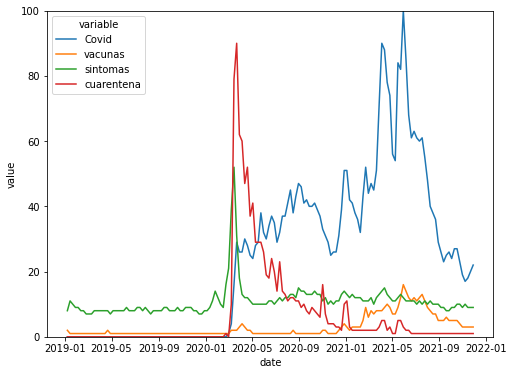

In [ ]:
import pandas as pd

from pytrends.request import TrendReq
import seaborn as sns
import matplotlib.pyplot as plt

pytrends = TrendReq(hl='en-US', tz=360)
kw_list = ['Covid', 'vacunas', 'sintomas', 'cuarentena']
pytrends.build_payload(kw_list, cat=0, timeframe='2019-01-01 2021-12-01', geo='AR', gprop='')
df = pytrends.interest_over_time()
df= df.reset_index()

df=pd.melt(df, value_vars=['Covid', 'vacunas', 'sintomas', 'cuarentena'], id_vars='date')
plt.figure(figsize=(8, 6))

ax = sns.lineplot(x="date", y='value', hue='variable',  data=df)
ax.set(ylim=(0, 100))



df.to_csv('trends2.csv', index=False)